In [1]:
import os
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import math
from pathlib import Path
import pandas as pd
import seaborn as sns

# Add project root to path
# PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Added {PROJECT_ROOT} to Python path")

from neural_networks.drm import DiscreteRepresentationsModel
from data_generation.models.tech_substitution import TechnologySubstitution, NumericalSolver
from data_generation.simulations.grid import tangent_transformation

Added /home/julian/tuberlin/projects/mdp-world-model to Python path


In [2]:
def load_model(model_path, use_enhanced_control_gate=False):
    """
    Load a trained DRM model from a checkpoint file
    
    Args:
        model_path: Path to the checkpoint file
        use_enhanced_control_gate: If True, use the enhanced FiLM-inspired control gate
                                  instead of the original control gate
    """
    # Load the saved model with weights_only=False (since we need the config too)
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    print("Model configuration:")
    for key, value in config.items():
        print(f" {key}: {value}")
    
    # Add enhanced control gate parameter to config if not present
    if 'use_enhanced_control_gate' not in config:
        config['use_enhanced_control_gate'] = use_enhanced_control_gate
        print(f" use_enhanced_control_gate: {use_enhanced_control_gate} (added)")
    
    # Recreate the model architecture
    model = DiscreteRepresentationsModel(
        obs_dim=config['obs_dim'],
        control_dim=config['control_dim'],
        num_states=config['num_states'],
        hidden_dim=config['hidden_dim'],
    )
    
    # Handle the case where we're loading weights from an old model into a new architecture
    if 'use_enhanced_control_gate' not in checkpoint['config'] and use_enhanced_control_gate:
        print("\nWARNING: Loading weights from a model with the original control gate into a model with enhanced control gate.")
        print("Some weights may not be correctly loaded.")
        
        # Create a new state dict with only the matching keys
        original_state_dict = checkpoint['model_state_dict']
        new_state_dict = {}
        
        # Only copy over the weights for components that exist in both models
        for key, value in original_state_dict.items():
            if key in model.state_dict():
                if model.state_dict()[key].shape == value.shape:
                    new_state_dict[key] = value
                else:
                    print(f"Skipping parameter {key} due to shape mismatch.")
            else:
                print(f"Parameter {key} from original model not found in new model.")
        
        # Load the filtered state dict
        model.load_state_dict(new_state_dict, strict=False)
    else:
        # Standard case: either we're not changing architecture or the checkpoint already has the right architecture
        try:
            model.load_state_dict(checkpoint['model_state_dict'])
        except Exception as e:
            print(f"\nWARNING: Error loading model weights: {e}")
            print("This might be due to architecture changes. Using model with random weights.")
    
    # Set the model to evaluation mode
    model.eval()
    print(f"\nModel loaded successfully!")
    print(f"Trained for {checkpoint['epoch']+1} epochs")
    print(f"Final validation loss: {checkpoint.get('val_loss', 'N/A')}")
    return model, config

In [78]:
#run_id = "run_20250303_104531" # # 4 states, delta t = 3
#file_name = run_id + "/drm_final_20250303_104531.pt"
#run_id = "run_20250305_100654" # 4 states, delta t = 15
#file_name = run_id + "/drm_final_20250305_100654.pt"
# run_id = "run_20250305_114702" # # 3 states, delta t = 3
# file_name = run_id + "/drm_final_20250305_114702.pt"
#run_id = "run_20250305_185432" # 4 states, delta t = 3, div_loss 0.5
#file_name = run_id + "/drm_checkpoint_epoch80_20250305_185432.pt"
#run_id = "run_20250305_193459" #  3 states, delta t = 3, #div_loss 1.0
#file_name = run_id + "/drm_final_20250305_193459.pt"

#run_id = "run_20250307_152907" #  4 states, delta t = 3, #div_loss 0.5, control_gate
#file_name = run_id + "/drm_final_20250307_152907.pt"
#run_id = "run_20250307_161324" #  3 states, delta t = 3, control_gate, no more div_loss
#file_name = run_id + "/drm_final_20250307_161324.pt"
#run_id = "run_20250307_164741" #  3 states, delta t = 3, FiLM control_gate, no more div_loss
#file_name = run_id + "/drm_final_20250307_164741.pt"
#run_id = "run_20250310_120238" # no value, just state,  3 states, delta t = 2.65, FiLM control_gate, no more div_loss
#file_name = run_id + "/drm_final_20250310_120238.pt"
#run_id = "run_20250310_120429" # no state loss just value,  3 states, delta t = 2.65, FiLM control_gate, no more div_loss
#file_name = run_id + "/drm_final_20250310_120429.pt"
run_id = "run_20250310_135837" # value 10, state_loss 1,  3 states, delta t = 2.65, FiLM control_gate, no more div_loss
file_name = run_id + "/drm_final_20250310_135837.pt"





model_path = Path(PROJECT_ROOT) / "neural_networks" / "output" / file_name

In [79]:
# Load the model
model, config = load_model(model_path)

Model configuration:
 obs_dim: 2
 control_dim: 1
 num_states: 3
 hidden_dim: 128
 use_enhanced_control_gate: False (added)

Model loaded successfully!
Trained for 100 epochs
Final validation loss: 0.013961509597720578


###  Add functions to explore state probabilities

In [80]:
def explore_state_probabilities(model, x_points, solver = None, calc_value=False):
    """Get state probabilities for a set of points"""
    with torch.no_grad():
        state_probs = model.get_state_probs(x_points)
    
    # Print results
    print("\nState probabilities:")
    if not calc_value:
        for i in range(len(x_points)):
            print(f"Point {x_points[i].detach().numpy()}:" 
                f"{np.round(state_probs[i].detach().numpy(), 2)}")
    else:
        for i in range(len(x_points)):
            value = solver.f_v(x_points[i].detach().numpy())
            print(f"Point {x_points[i].detach().numpy()}:"
                f"{np.round(state_probs[i].detach().numpy(), 2)} "
                     f"Value: {value:.2f}")
    
    return state_probs


In [81]:
def visualize_state_space_in_zspace(model, 
                                   z_bounds=[(0, 1), (0, 1)],
                                   transformations=None,
                                   num_points=1000,
                                   num_ticks=5,
                                   cols_per_row=2,
                                   figsize=(12, 10)):
    """
    Visualize the state probabilities in z-space (transformed space) with x-space coordinate labels,
    in a grid layout with quadratic plots.
    
    Args:
        model: Trained DRM model
        z_bounds: List of tuples [(z1_min, z1_max), (z2_min, z2_max)] for the z-space bounds
        transformations: List of tuples (transform_func, inverse_transform_func, derivative_func)
            same format as in Grid class
        num_points: Number of points in each dimension of the mesh
        num_ticks: Number of ticks to show on each axis
        cols_per_row: Number of plots per row
        figsize: Figure size
    """
    if transformations is None:
        raise ValueError("Transformations must be provided")
    
    # Unpack the transformation functions
    _, inverse_transforms, _ = zip(*transformations)
    
    # Create a grid of points in z-space
    z1_values = np.linspace(z_bounds[0][0], z_bounds[0][1], num_points)
    z2_values = np.linspace(z_bounds[1][0], z_bounds[1][1], num_points)
    
    z1_grid, z2_grid = np.meshgrid(z1_values, z2_values)
    z1_flat, z2_flat = z1_grid.flatten(), z2_grid.flatten()
    
    # Transform z-space coordinates to x-space for the input to the model
    x1_flat = np.array([inverse_transforms[0](z) for z in z1_flat])
    x2_flat = np.array([inverse_transforms[1](z) for z in z2_flat])
    
    # Create input tensor for model
    x_test = torch.tensor(np.column_stack((x1_flat, x2_flat)), dtype=torch.float32)
    
    # Get state probabilities
    with torch.no_grad():
        state_probs = model.get_state_probs(x_test)
    
    # Define grid layout
    num_states = state_probs.shape[1]
    cols = min(cols_per_row, num_states)
    rows = math.ceil(num_states / cols)
    
    # Create figure without constrained_layout
    fig, axes = plt.subplots(rows, cols, figsize=figsize, 
                           squeeze=False)  # Don't squeeze to keep 2D array
    
    # Generate tick positions for z-space
    z1_ticks = np.linspace(z_bounds[0][0], z_bounds[0][1], num_ticks)
    z2_ticks = np.linspace(z_bounds[1][0], z_bounds[1][1], num_ticks)
    
    # Format functions for ticks (z to x transformation)
    def format_x1_ticks(z, pos):
        x = inverse_transforms[0](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    def format_x2_ticks(z, pos):
        x = inverse_transforms[1](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    # Plot each state
    for state in range(num_states):
        row_idx = state // cols
        col_idx = state % cols
        ax = axes[row_idx, col_idx]
        
        probs = state_probs[:, state].detach().numpy().reshape(z1_grid.shape)
        im = ax.pcolormesh(z1_grid, z2_grid, probs, vmin=0, vmax=1, cmap='viridis')
        ax.set_title(f'State {state+1} Probability')
        
        # Set ticks
        ax.set_xticks(z1_ticks)
        ax.set_yticks(z2_ticks)
        
        # Set custom tick formatters
        ax.xaxis.set_major_formatter(FuncFormatter(format_x1_ticks))
        ax.yaxis.set_major_formatter(FuncFormatter(format_x2_ticks))
        
        # Set labels
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add colorbar (without using plt.colorbar which can cause layout issues)
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Probability')
    
    # Hide unused subplots
    for i in range(num_states, rows * cols):
        row_idx = i // cols
        col_idx = i % cols
        axes[row_idx, col_idx].set_visible(False)
    
    # Instead of tight_layout, adjust spacing manually
    plt.subplots_adjust(wspace=0.6, hspace=0.5)
    plt.show()
    
    return fig, axes

In [82]:
def visualize_dominant_states(model, 
                              z_bounds=[(0, 1), (0, 1)],
                              transformations=None,
                              num_points=50,
                              num_ticks=5,
                              figsize=(10, 8)):
    """
    Visualize the dominant state (state with highest probability) at each point in z-space.
    
    Args:
        model: Trained DRM model
        z_bounds: List of tuples [(z1_min, z1_max), (z2_min, z2_max)] for the z-space bounds
        transformations: List of tuples (transform_func, inverse_transform_func, derivative_func)
        num_points: Number of points in each dimension of the mesh
        num_ticks: Number of ticks to show on each axis
        figsize: Figure size
    """
    if transformations is None:
        raise ValueError("Transformations must be provided")
    
    # Unpack the transformation functions
    _, inverse_transforms, _ = zip(*transformations)
    
    # Create a grid of points in z-space
    z1_values = np.linspace(z_bounds[0][0], z_bounds[0][1], num_points)
    z2_values = np.linspace(z_bounds[1][0], z_bounds[1][1], num_points)
    
    z1_grid, z2_grid = np.meshgrid(z1_values, z2_values)
    z1_flat, z2_flat = z1_grid.flatten(), z2_grid.flatten()
    
    # Transform z-space coordinates to x-space for the input to the model
    x1_flat = np.array([inverse_transforms[0](z) for z in z1_flat])
    x2_flat = np.array([inverse_transforms[1](z) for z in z2_flat])
    
    # Create input tensor for model
    x_test = torch.tensor(np.column_stack((x1_flat, x2_flat)), dtype=torch.float32)
    
    # Get state probabilities
    with torch.no_grad():
        state_probs = model.get_state_probs(x_test)
    
    # Find the dominant state (index of maximum probability) for each point
    dominant_states = torch.argmax(state_probs, dim=1).numpy()
    dominant_states_grid = dominant_states.reshape(z1_grid.shape)
    
    # Get number of states for colormap
    num_states = state_probs.shape[1]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Custom colormap with distinct colors for each state
    cmap = plt.cm.get_cmap('tab10', num_states)
    
    # Plot dominant states
    im = ax.pcolormesh(z1_grid, z2_grid, dominant_states_grid, cmap=cmap, 
                       vmin=-0.5, vmax=num_states-0.5)
    
    # Set title and labels
    ax.set_title('Dominant State Regions')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    
    # Format functions for ticks (z to x transformation)
    def format_x1_ticks(z, pos):
        x = inverse_transforms[0](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    def format_x2_ticks(z, pos):
        x = inverse_transforms[1](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    # Set ticks
    z1_ticks = np.linspace(z_bounds[0][0], z_bounds[0][1], num_ticks)
    z2_ticks = np.linspace(z_bounds[1][0], z_bounds[1][1], num_ticks)
    ax.set_xticks(z1_ticks)
    ax.set_yticks(z2_ticks)
    
    # Set custom tick formatters
    ax.xaxis.set_major_formatter(FuncFormatter(format_x1_ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(format_x2_ticks))
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add colorbar with discrete ticks for each state
    cbar = plt.colorbar(im, ax=ax, ticks=np.arange(num_states))
    cbar.set_label('Dominant State')
    cbar.ax.set_yticklabels([f'State {i+1}' for i in range(num_states)])
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [83]:
def visualize_value_function(model, 
                             value_function=None,
                             z_bounds=[(0, 1), (0, 1)],
                             transformations=None,
                             num_points=50,
                             num_ticks=5,
                             figsize=(10, 8)):
    """
    Visualize a provided value function across the z-space.
    
    Args:
        model: Trained DRM model (not used for computation, only for context)
        value_function: Function that takes x-space coordinates and returns a value
        z_bounds: List of tuples [(z1_min, z1_max), (z2_min, z2_max)] for the z-space bounds
        transformations: List of tuples (transform_func, inverse_transform_func, derivative_func)
        num_points: Number of points in each dimension of the mesh
        num_ticks: Number of ticks to show on each axis
        figsize: Figure size
    """
    if transformations is None:
        raise ValueError("Transformations must be provided")
    
    if value_function is None:
        raise ValueError("A value_function must be provided")
    
    # Unpack the transformation functions
    _, inverse_transforms, _ = zip(*transformations)
    
    # Create a grid of points in z-space
    z1_values = np.linspace(z_bounds[0][0], z_bounds[0][1], num_points)
    z2_values = np.linspace(z_bounds[1][0], z_bounds[1][1], num_points)
    
    z1_grid, z2_grid = np.meshgrid(z1_values, z2_values)
    z1_flat, z2_flat = z1_grid.flatten(), z2_grid.flatten()
    
    # Transform z-space coordinates to x-space for evaluation
    x_coords = []
    for i in range(len(z1_flat)):
        x1 = inverse_transforms[0](z1_flat[i])
        x2 = inverse_transforms[1](z2_flat[i])
        x_coords.append((x1, x2))
    
    # Compute values using the provided function
    values = np.array([value_function(x) for x in x_coords])
    
    # Reshape values for plotting
    values_grid = values.reshape(z1_grid.shape)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot value function
    im = ax.pcolormesh(z1_grid, z2_grid, values_grid, cmap='viridis')
    
    # Set title and labels
    ax.set_title('Value Function')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    
    # Format functions for ticks (z to x transformation)
    def format_x1_ticks(z, pos):
        x = inverse_transforms[0](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    def format_x2_ticks(z, pos):
        x = inverse_transforms[1](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    # Set ticks
    z1_ticks = np.linspace(z_bounds[0][0], z_bounds[0][1], num_ticks)
    z2_ticks = np.linspace(z_bounds[1][0], z_bounds[1][1], num_ticks)
    ax.set_xticks(z1_ticks)
    ax.set_yticks(z2_ticks)
    
    # Set custom tick formatters
    ax.xaxis.set_major_formatter(FuncFormatter(format_x1_ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(format_x2_ticks))
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

## Add functions to explore predictions

In [84]:
def predict_next_state_and_value(model, x, c):
    """Predict next state and value for given input and control"""
    with torch.no_grad():
        # Get current state probabilities
        s_x = model.get_state_probs(x)
        
        # Predict next state
        s_y_pred = model.predict_next_state(s_x, c)
        
        # Compute value
        v_pred = model.compute_value(s_y_pred)
        
        return s_x, s_y_pred, v_pred

def simulate_trajectory(model, x_start, control, steps=10):
    """Simulate a trajectory from a starting point with given control"""
    x = x_start.clone()
    trajectory = [x.detach().numpy()]
    values = []
    
    # Convert control to tensor if it's not already
    if not isinstance(control, torch.Tensor):
        c = torch.tensor([[control]], dtype=torch.float32)
    else:
        c = control
    
    print(f"\nSimulating trajectory from {x.detach().numpy()} with control {c.detach().numpy()}:")
    print(f"Step 0: {x.detach().numpy()}")
    
    with torch.no_grad():
        for i in range(steps):
            # Get current state probabilities
            s_x = model.get_state_probs(x)
            
            # Predict next state probabilities
            s_y_pred = model.predict_next_state(s_x, c)
            
            # Compute value
            v_pred = model.compute_value(s_y_pred)
            values.append(v_pred.item())
            
            # This is where you would need to map from state probabilities back to observations
            # For now, we'll just use the value as a proxy
            print(f"Step {i+1}: State probs={s_y_pred.detach().numpy()[0]}, Value={v_pred.item():.4f}")
    
    return values

## Exploration

In [85]:
tech_model = TechnologySubstitution()
solver = NumericalSolver(tech_model)

In [86]:
# Create some test points
points = [
    [17.5, 0.05],  # tech 1 dominant
    [75.8, 1.3],     # tech 1 dominant
    [0.05, 17.5],  # tech 2 completly dominant
    [1.3, 75.8],  # tech 2 completly dominant
    [1.3, 3.0],  # tech 2 dominant
    [6.7, 17.5],  # tech 2 dominant
    [3.0, 3.0], # central point
    [3.0, 2.9], # central point
    [2.9, 3.0], # central point
    [400., 400.],
    [0.5, 1.0], # undecided
    [6.7, 3.0], # undecided space
    [17.5, 6.7], # undecided space
]
test_points = torch.tensor(points, dtype=torch.float32)

# Explore state probabilities
state_probs = explore_state_probabilities(model, test_points, solver=solver, calc_value=True)


State probabilities:
Point [17.5   0.05]:[1. 0. 0.] Value: 0.00
Point [75.8  1.3]:[1. 0. 0.] Value: 0.02
Point [ 0.05 17.5 ]:[0. 1. 0.] Value: 1.00
Point [ 1.3 75.8]:[0. 1. 0.] Value: 0.98
Point [1.3 3. ]:[0.24 0.63 0.13] Value: 0.70
Point [ 6.7 17.5]:[0.21 0.6  0.18] Value: 0.72
Point [3. 3.]:[0.31 0.51 0.18] Value: 0.50
Point [3.  2.9]:[0.31 0.51 0.18] Value: 0.49
Point [2.9 3. ]:[0.31 0.52 0.17] Value: 0.51
Point [400. 400.]:[0. 0. 1.] Value: 0.50
Point [0.5 1. ]:[0.27 0.64 0.08] Value: 0.67
Point [6.7 3. ]:[0.38 0.4  0.22] Value: 0.31
Point [17.5  6.7]:[0.38 0.34 0.28] Value: 0.28


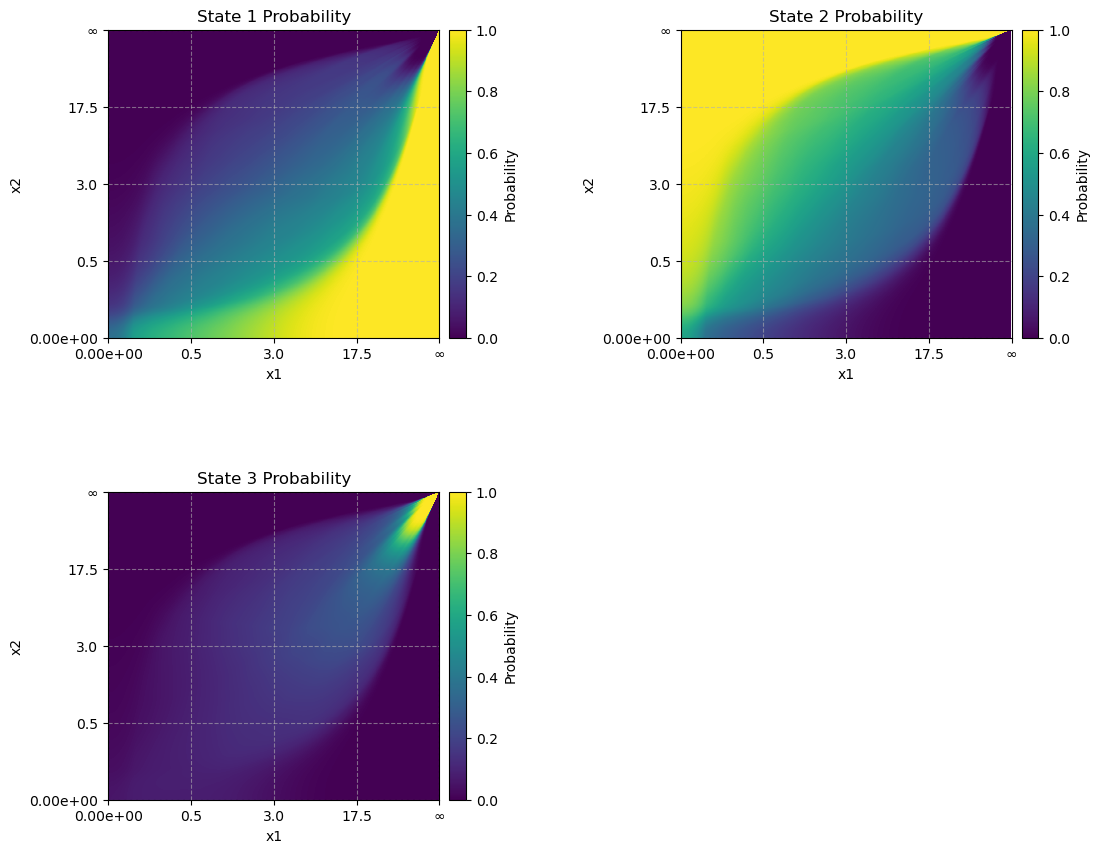

(<Figure size 1200x1000 with 7 Axes>,
 array([[<Axes: title={'center': 'State 1 Probability'}, xlabel='x1', ylabel='x2'>,
         <Axes: title={'center': 'State 2 Probability'}, xlabel='x1', ylabel='x2'>],
        [<Axes: title={'center': 'State 3 Probability'}, xlabel='x1', ylabel='x2'>,
         <Axes: >]], dtype=object))

In [87]:
transformations = [tangent_transformation(3, 0.5), tangent_transformation(3, 0.5)]
visualize_state_space_in_zspace(
    model,
    z_bounds=[(0, 1), (0, 1)],  # Z-space is typically [0,1] for tangent transformation
    transformations=transformations,
    num_points=1000,
    cols_per_row=2
)

/home/julian/tuberlin/projects/mdp-world-model/data_generation/models/tech_substitution.py:251: RuntimeWarning: invalid value encountered in scalar divide
  return y2 / (y1+y2 +1e-10)


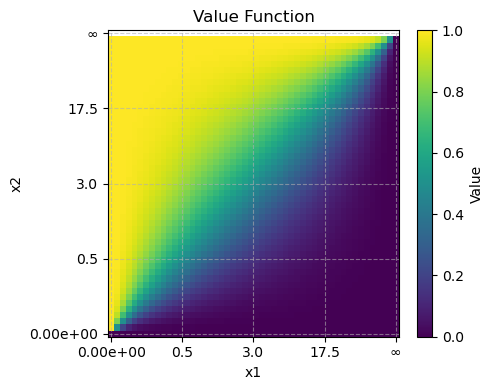

(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': 'Value Function'}, xlabel='x1', ylabel='x2'>)

In [88]:
visualize_value_function(
    model,
    value_function=solver.f_v,
    z_bounds=[(0, 1), (0, 1)],
    transformations=transformations,
    num_points=50,
    num_ticks=5,
    figsize=(5,4)
)

/tmp/ipykernel_4685/2578279125.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_states)


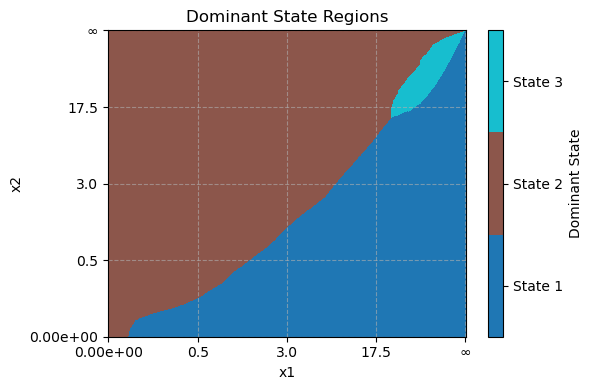

(<Figure size 600x400 with 2 Axes>,
 <Axes: title={'center': 'Dominant State Regions'}, xlabel='x1', ylabel='x2'>)

In [89]:
visualize_dominant_states(
    model,
    z_bounds=[(0, 1), (0, 1)],  
    transformations=transformations,
    num_points=1000,
    num_ticks=5,
    figsize=(6,4)
)

### Transiiton probabilities

In [90]:
def analyze_state_transitions(model, 
                             transformations, 
                             control_values=[0.5, 1.0],
                             z_bounds=[(0, 1), (0, 1)],
                             num_points=32,
                             assignment_method='argmax',
                             device='cpu'):
    """
    Analyze and visualize state transitions for different control values.
    """
    # Move model to device
    model = model.to(device)
    model.eval()
    
    # Unpack transformations
    _, inverse_transforms, _ = zip(*transformations)
    
    # CORRECTED: Create grid in z-space avoiding the z=1 boundary point
    epsilon = 1e-5  # Small adjustment to avoid exactly z=1
    z1 = np.linspace(z_bounds[0][0], z_bounds[0][1] - epsilon, num_points)
    z2 = np.linspace(z_bounds[1][0], z_bounds[1][1] - epsilon, num_points)
    Z1, Z2 = np.meshgrid(z1, z2)
    
    # Flatten grid
    z1_flat = Z1.flatten()
    z2_flat = Z2.flatten()
    
    # Transform to x-space (original space)
    x1_flat = np.array([inverse_transforms[0](z) for z in z1_flat])
    x2_flat = np.array([inverse_transforms[1](z) for z in z2_flat])
    
    # Prepare input for model
    x_batch = torch.tensor(np.column_stack((x1_flat, x2_flat)), dtype=torch.float32).to(device)
    
    # Get current state probabilities with error checking
    with torch.no_grad():
        logits = model.encoder(x_batch)
        # Check for NaN in logits
        if torch.isnan(logits).any():
            print("WARNING0: NaN values detected in encoder output logits!")
            logits = torch.nan_to_num(logits, nan=0.0)
        
        # Apply softmax with temperature to stabilize
        current_state_probs = torch.nn.functional.softmax(logits, dim=1)
        
        # Check for NaN again
        if torch.isnan(current_state_probs).any():
            print("WARNING1: NaN values detected in current_state_probs after softmax!")
            current_state_probs = torch.nan_to_num(current_state_probs, nan=0.0)
            # Renormalize to ensure valid probabilities
            row_sums = current_state_probs.sum(dim=1, keepdim=True)
            current_state_probs = current_state_probs / torch.clamp(row_sums, min=1e-10)
    
    num_states = current_state_probs.shape[1]
    results = {}
    
    # Calculate average probabilities for the unusual assignment method
    avg_state_probs = torch.mean(current_state_probs, dim=0)
    print(f"Average state probabilities: {avg_state_probs.cpu().numpy()}")
    
    # Debug info
    print(f"Min/max state probabilities: {torch.min(current_state_probs).item()}, {torch.max(current_state_probs).item()}")
    
    # Clamp values for stability
    current_state_probs = torch.clamp(current_state_probs, min=1e-10, max=1.0)
    
    # Determine state assignments based on chosen method
    if assignment_method == 'argmax':
        # Assign each point to its most likely state
        state_assignments = torch.argmax(current_state_probs, dim=1).cpu().numpy()
    elif assignment_method == 'unusual':
        # Calculate "unusualness" ratio with careful division
        avg_state_probs_safe = torch.clamp(avg_state_probs, min=1e-10)
        unusualness = current_state_probs / avg_state_probs_safe.unsqueeze(0)
        state_assignments = torch.argmax(unusualness, dim=1).cpu().numpy()
    elif assignment_method == 'soft':
        # For soft, we'll handle differently
        state_assignments = None
    else:
        raise ValueError(f"Unknown assignment method: {assignment_method}")
    
    # Debug assignments
    if state_assignments is not None:
        unique_assignments = np.unique(state_assignments)
        print(f"Unique state assignments: {unique_assignments}")
        assignment_counts = np.bincount(state_assignments, minlength=num_states)
        print(f"Assignment counts: {assignment_counts}")
    
    for control_value in control_values:
        # Prepare control tensor
        control_batch = torch.full((x_batch.shape[0], 1), control_value, dtype=torch.float32).to(device)
        
        # Predict next state with error checking
        with torch.no_grad():
            # Concatenate state probs with control
            predictor_input = torch.cat([current_state_probs, control_batch], dim=1)
            
            # Check for NaN
            if torch.isnan(predictor_input).any():
                print("WARNING2: NaN detected in predictor_input!")
                predictor_input = torch.nan_to_num(predictor_input, nan=0.0)
            
            # Run through predictor
            next_logits = model.predict_next_state(predictor_input)
            
            # Check for NaN
            if torch.isnan(next_logits).any():
                print("WARNING3: NaN detected in predictor output!")
                next_logits = torch.nan_to_num(next_logits, nan=0.0)
                
            # Get probabilities
            next_state_probs = torch.nn.functional.softmax(next_logits, dim=1)
            
            # Final NaN check
            if torch.isnan(next_state_probs).any():
                print("WARNING4: NaN detected in next_state_probs!")
                next_state_probs = torch.nan_to_num(next_state_probs, nan=0.0)
                # Renormalize
                row_sums = next_state_probs.sum(dim=1, keepdim=True)
                next_state_probs = next_state_probs / torch.clamp(row_sums, min=1e-10)
        
        # Move to CPU for analysis
        next_state_probs = next_state_probs.cpu()
        current_state_probs_cpu = current_state_probs.cpu()
        
        # Initialize transition matrix
        transition_matrix = np.zeros((num_states, num_states))
        
        try:
            if assignment_method == 'soft':
                # Soft assignment - use outer products weighted by current state probability
                for i in range(x_batch.shape[0]):
                    current_probs = current_state_probs_cpu[i].numpy()
                    next_probs = next_state_probs[i].numpy()
                    
                    # For each possible current state, distribute its probability to next states
                    for current_state in range(num_states):
                        transition_matrix[current_state] += current_probs[current_state] * next_probs
            else:
                # Hard assignment - group points by their assigned state
                for state in range(num_states):
                    # Get indices of points assigned to this state
                    state_indices = np.where(state_assignments == state)[0]
                    
                    if len(state_indices) > 0:
                        # Get the average predicted next state distribution for these points
                        avg_next_state = torch.mean(next_state_probs[state_indices], dim=0).numpy()
                        transition_matrix[state] = avg_next_state
                    else:
                        print(f"Warning: No points assigned to state {state+1}")
                        # Fill with uniform distribution for stability
                        transition_matrix[state] = np.ones(num_states) / num_states
            
            # Ensure rows sum to 1
            row_sums = transition_matrix.sum(axis=1, keepdims=True)
            transition_matrix = np.divide(transition_matrix, row_sums, 
                                         out=np.zeros_like(transition_matrix), 
                                         where=row_sums!=0)
            
        except Exception as e:
            print(f"Error computing transition matrix: {e}")
            # Provide a fallback uniform transition matrix
            transition_matrix = np.ones((num_states, num_states)) / num_states
        
        results[control_value] = transition_matrix
    
    # Visualize the transition matrices
    visualize_transition_matrices(results, control_values)
    
    return results

def visualize_transition_matrices(transition_matrices, control_values):
    """
    Visualize transition matrices as heatmaps and tables.
    
    Args:
        transition_matrices: Dictionary of transition matrices
        control_values: List of control values used
    """
    num_states = transition_matrices[control_values[0]].shape[0]
    
    # 1. Create heatmaps
    fig, axes = plt.subplots(1, len(control_values), figsize=(len(control_values)*6, 5))
    if len(control_values) == 1:
        axes = [axes]
    
    for i, control in enumerate(control_values):
        ax = axes[i]
        matrix = transition_matrices[control]
        
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", 
                   vmin=0, vmax=1, ax=ax, cbar=True)
        
        ax.set_title(f"Transition Probabilities (c={control})")
        ax.set_xlabel("Next State")
        ax.set_ylabel("Current State")
        ax.set_xticklabels([f"S{j+1}" for j in range(num_states)])
        ax.set_yticklabels([f"S{j+1}" for j in range(num_states)])
    
    plt.tight_layout()
    plt.show()
    
    # 2. Create pandas DataFrames for better table view
    for control in control_values:
        matrix = transition_matrices[control]
        df = pd.DataFrame(matrix, 
                         index=[f"State {i+1}" for i in range(num_states)],
                         columns=[f"State {i+1}" for i in range(num_states)])
        
        print(f"\nTransition Probabilities for c={control}:")
        print(df.round(3))

In [91]:
analyze_state_transitions(model, 
                             transformations, 
                             control_values=[0.5, 1.0],
                             z_bounds=[(0, 1), (0, 1)],
                             num_points=64,
                             assignment_method='argmax')

Average state probabilities: [0.40248585 0.51010376 0.08741038]
Min/max state probabilities: 0.0, 1.0
Unique state assignments: [0 1 2]
Assignment counts: [1629 2388   79]


TypeError: DiscreteRepresentationsModel.predict_next_state() missing 1 required positional argument: 'c'

### Value

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import math
from torch.utils.data import DataLoader

def visualize_value_predictions(model, 
                               dataset,
                               transformations,
                               z_bounds=[(0, 1), (0, 1)],
                               num_points=1000,
                               batch_size=128,
                               figsize=(14, 6),
                               num_ticks=5,
                               device='cpu'):
    """
    Visualizes the value predictions for both actual and predicted next states.
    
    Args:
        model: Trained DRM model
        dataset: Dataset containing (x,c,y,v_true) samples
        transformations: List of transformation tuples
        z_bounds: Bounds for the z-space visualization
        num_points: Number of points to sample from the dataset
        batch_size: Batch size for processing
        figsize: Size of the figure
        num_ticks: Number of ticks on each axis
        device: Device to run model on ('cpu' or 'cuda')
    """
    # Move model to device and set to eval mode
    model = model.to(device)
    model.eval()
    
    # Unpack transformations
    transform_funcs, inverse_transforms, _ = zip(*transformations)
    
    # Create dataloader to sample from dataset
    indices = np.random.choice(len(dataset), min(num_points, len(dataset)), replace=False)
    
    # Initialize empty arrays to collect results
    all_x1 = []
    all_x2 = []
    all_z1 = []
    all_z2 = []
    all_true_values = []
    all_pred_values = []
    
    # Process batches
    with torch.no_grad():
        for idx in range(0, len(indices), batch_size):
            batch_indices = indices[idx:idx+batch_size]
            
            # Get batch data
            batch_data = [dataset[i] for i in batch_indices]
            x_batch = torch.stack([item[0] for item in batch_data]).to(device)
            c_batch = torch.stack([item[1] for item in batch_data]).to(device)
            y_batch = torch.stack([item[2] for item in batch_data]).to(device)
            
            # Model forward pass
            # Get current state encoding
            s_x = model.get_state_probs(x_batch)
            
            # Get actual next state encoding
            s_y = model.get_state_probs(y_batch)
            
            # Get predicted next state
            s_y_pred = model.predict_next_state(s_x, c_batch)
            
            # Compute values for both
            v_true = model.compute_value(s_y).cpu().numpy()
            v_pred = model.compute_value(s_y_pred).cpu().numpy()
            
            # Extract original space coordinates
            x1 = x_batch[:, 0].cpu().numpy()
            x2 = x_batch[:, 1].cpu().numpy()
            
            # Transform to z-space for plotting
            z1 = np.array([transform_funcs[0](x) for x in x1])
            z2 = np.array([transform_funcs[1](x) for x in x2])
            
            # Collect results
            all_x1.extend(x1)
            all_x2.extend(x2)
            all_z1.extend(z1)
            all_z2.extend(z2)
            all_true_values.extend(v_true)
            all_pred_values.extend(v_pred)
    
    # Convert to numpy arrays
    all_z1 = np.array(all_z1)
    all_z2 = np.array(all_z2)
    all_true_values = np.array(all_true_values).flatten()
    all_pred_values = np.array(all_pred_values).flatten()
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Common colormap range for better comparison
    vmin = min(np.min(all_true_values), np.min(all_pred_values))
    vmax = max(np.max(all_true_values), np.max(all_pred_values))
    
    # Plot actual value
    im1 = axes[0].scatter(all_z1, all_z2, c=all_true_values, cmap='viridis', 
                         alpha=0.7, edgecolor='none', vmin=vmin, vmax=vmax)
    axes[0].set_title('Value from Actual Next State')
    
    # Plot predicted value
    im2 = axes[1].scatter(all_z1, all_z2, c=all_pred_values, cmap='viridis', 
                         alpha=0.7, edgecolor='none', vmin=vmin, vmax=vmax)
    axes[1].set_title('Value from Predicted Next State')
    
    # Generate tick positions for z-space
    z1_ticks = np.linspace(z_bounds[0][0], z_bounds[0][1], num_ticks)
    z2_ticks = np.linspace(z_bounds[1][0], z_bounds[1][1], num_ticks)
    
    # Format functions for ticks (z to x transformation)
    def format_x1_ticks(z, pos):
        x = inverse_transforms[0](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    def format_x2_ticks(z, pos):
        x = inverse_transforms[1](z)
        if np.isinf(x) or x > 1000:
            return "∞"
        elif x < 0.1:
            return f"{x:.2e}"
        else:
            return f"{x:.1f}"
    
    # Apply axis configurations to both plots
    for ax in axes:
        # Set ticks
        ax.set_xticks(z1_ticks)
        ax.set_yticks(z2_ticks)
        
        # Set custom tick formatters
        ax.xaxis.set_major_formatter(FuncFormatter(format_x1_ticks))
        ax.yaxis.set_major_formatter(FuncFormatter(format_x2_ticks))
        
        # Set labels
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add colorbar
    cbar = fig.colorbar(im1, ax=axes.tolist(), orientation='horizontal', pad=0.1)
    cbar.set_label('Value (Market Share)')
    
    # Compute error metrics
    mse = np.mean((all_true_values - all_pred_values)**2)
    mae = np.mean(np.abs(all_true_values - all_pred_values))
    
    # Add metrics to the figure
    fig.suptitle(f'Value Prediction Comparison (MSE: {mse:.4f}, MAE: {mae:.4f})')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.15)
    plt.show()
    
    return fig, axes

Using table: TechnologySubstitution_gamma2
Columns: ['run_id', 'trajectory_id', 't0', 't1', 'x0', 'x1', 'c0', 'y0', 'y1']
Found 20000 rows in the dataset
Validating first 5 samples:
Sample 0: x=[0.0036976  0.03885311], c=[1.], y=[0.0037101  0.04406333], v_true=[0.92233956]
Sample 1: x=[0.0037101  0.04406333], c=[1.], y=[0.0037227  0.05145733], v_true=[0.93253535]
Sample 2: x=[0.0037227  0.05145733], c=[1.], y=[0.00373539 0.06298907], v_true=[0.94401765]
Sample 3: x=[0.00373539 0.06298907], c=[1.], y=[0.00374815 0.08423356], v_true=[0.95739853]
Sample 4: x=[0.00374815 0.08423356], c=[1.], y=[0.00376086 0.14125176], v_true=[0.9740653]


/tmp/ipykernel_5180/1565963482.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


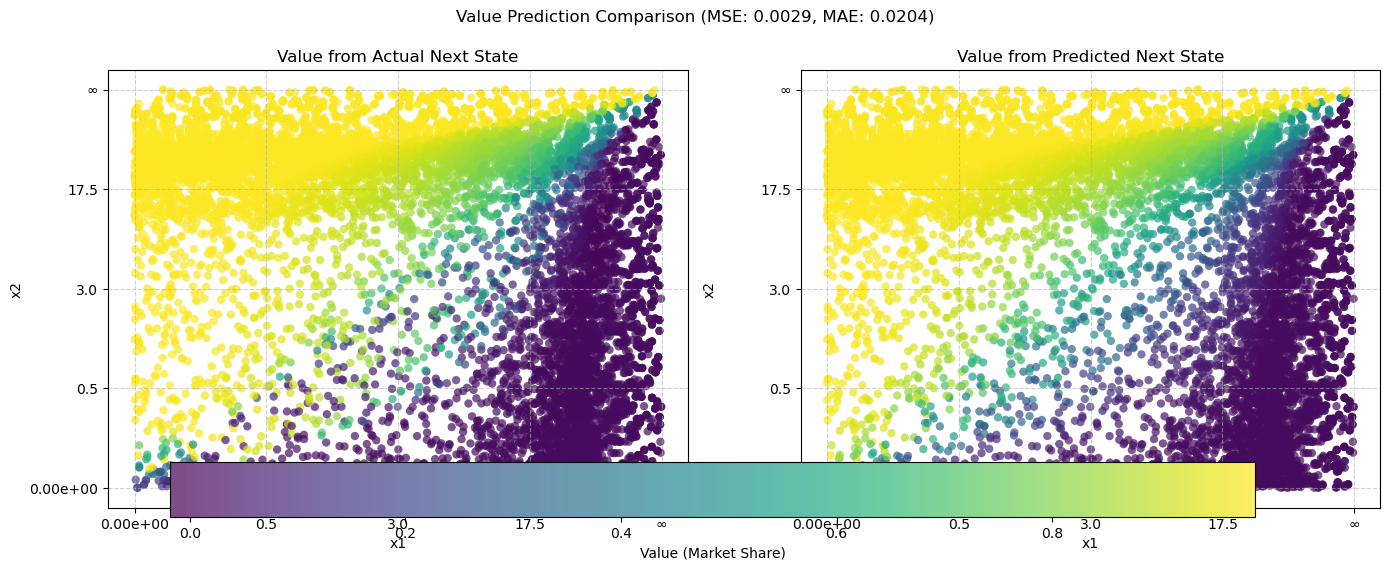

(<Figure size 1400x600 with 3 Axes>,
 array([<Axes: title={'center': 'Value from Actual Next State'}, xlabel='x1', ylabel='x2'>,
        <Axes: title={'center': 'Value from Predicted Next State'}, xlabel='x1', ylabel='x2'>],
       dtype=object))

In [ ]:
# Create the TechSubstitutionDataset instance (if not already available)
from neural_networks.drm_dataset import TechSubstitutionDataset
project_root = str(Path(os.getcwd()).parent.parent)
db_path = os.path.join(project_root, 'datasets', 'results', 'tech_toy2.db')
dataset = TechSubstitutionDataset(db_path, solver)

# Call the visualization function
visualize_value_predictions(
    model=model, 
    dataset=dataset,
    transformations=transformations,
    z_bounds=[(0, 1), (0, 1)],  # Adjust based on your transformations
    num_points=10000  # Adjust based on your computational resources
)

In [ ]:
os.getcwd()

'/home/julian/tuberlin/projects/mdp-world-model/neural_networks/tests'

In [ ]:
sys.path

['/home/julian/tuberlin/projects/mdp-world-model',
 '/home/julian/anaconda3/envs/mdp-world-model/lib/python312.zip',
 '/home/julian/anaconda3/envs/mdp-world-model/lib/python3.12',
 '/home/julian/anaconda3/envs/mdp-world-model/lib/python3.12/lib-dynload',
 '',
 '/home/julian/anaconda3/envs/mdp-world-model/lib/python3.12/site-packages']